In [ ]:
!pip install -q transformers datasets accelerate scikit-learn

In [ ]:
from google.colab import files

print("Please upload the 'ngo_dataset_balanced_quick.csv' file:")
uploaded = files.upload()

Please upload the 'ngo_dataset_balanced_quick.csv' file:


Saving final_rebuilt_dataset (1).csv to final_rebuilt_dataset (1).csv


In [ ]:
import pandas as pd
import torch
from torch import nn
from sklearn.model_selection import train_test_split
from transformers import RobertaTokenizer, RobertaForSequenceClassification, Trainer, TrainingArguments
from datasets import Dataset

# 1. Load your NEW rebuilt file
df = pd.read_csv('final_rebuilt_dataset (1).csv')

# 2. Map priorities
label_map = {'CRITICAL': 0, 'HIGH': 1, 'MEDIUM': 2, 'LOW': 3}
df['label'] = df['priority'].map(label_map)

# 3. Split (80/20)
train_df, val_df = train_test_split(df, test_size=0.2, stratify=df['label'], random_state=42)

# 4. Convert to Hugging Face format
train_dataset = Dataset.from_pandas(train_df[['text', 'label']])
val_dataset = Dataset.from_pandas(val_df[['text', 'label']])

# 5. Tokenization
tokenizer = RobertaTokenizer.from_pretrained('roberta-base')
def tokenize_func(examples):
    return tokenizer(examples['text'], padding='max_length', truncation=True, max_length=128)

tokenized_train = train_dataset.map(tokenize_func, batched=True)
tokenized_val = val_dataset.map(tokenize_func, batched=True)

# 6. Model & Trainer
model = RobertaForSequenceClassification.from_pretrained('roberta-base', num_labels=4)

training_args = TrainingArguments(
    output_dir='./results',
    eval_strategy="epoch",      # How often to check the validation set
    save_strategy="epoch",      # MUST match eval_strategy to use load_best_model_at_end
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    num_train_epochs=15,
    weight_decay=0.01,
    load_best_model_at_end=True, # Now this will work!
    logging_steps=10
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
)

# 7. Train
trainer.train()

# 8. Test Function
def predict(text):
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True).to(model.device)
    with torch.no_grad():
        logits = model(**inputs).logits
    pred_idx = torch.argmax(logits, dim=1).item()
    return {v: k for k, v in label_map.items()}[pred_idx]

print(f"Test Prediction: {predict('People are dying and trapped, need immediate rescue!')}")

Map:   0%|          | 0/224 [00:00<?, ? examples/s]

Map:   0%|          | 0/56 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss
1,1.380539,1.277881
2,0.687901,0.223879
3,0.096371,0.012212
4,0.024094,0.003983
5,0.004666,0.002525
6,0.003784,0.001912
7,0.002904,0.001575
8,0.002408,0.001366
9,0.002141,0.001222
10,0.001841,0.001118


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

Test Prediction: CRITICAL


In [ ]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report
import numpy as np

# 1. Define how to calculate accuracy
def compute_metrics(eval_pred):
    labels = eval_pred.label_ids
    preds = eval_pred.predictions.argmax(-1)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='weighted')
    acc = accuracy_score(labels, preds)
    return {
        'accuracy': acc,
        'f1': f1,
        'precision': precision,
        'recall': recall
    }

# 2. Update your Trainer to include these metrics
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
    compute_metrics=compute_metrics, # Add this line!
)

# 3. Train and Save
trainer.train()
trainer.save_model("./final_ngo_model") # Saves weights + config
tokenizer.save_pretrained("./final_ngo_model")

# 4. Print the final detailed report
predictions = trainer.predict(tokenized_val)
y_pred = np.argmax(predictions.predictions, axis=-1)
print("\n--- FINAL ACCURACY REPORT ---")
print(classification_report(tokenized_val['label'], y_pred, target_names=list(label_map.keys())))

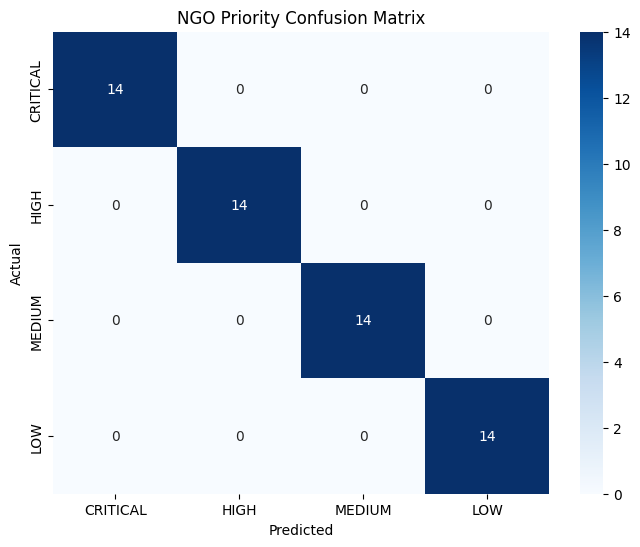

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 1. Get predictions from the trainer
output = trainer.predict(tokenized_val)
y_true = output.label_ids
y_pred = np.argmax(output.predictions, axis=-1)

# 2. Create the matrix
cm = confusion_matrix(y_true, y_pred)
labels = ['CRITICAL', 'HIGH', 'MEDIUM', 'LOW']

# 3. Plot
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('NGO Priority Confusion Matrix')
plt.show()

In [ ]:
test_scenarios = [
    "The roof of the clinic collapsed and people are trapped inside!", # Should be CRITICAL
    "We need more textbooks for the grade 5 students next month.",     # Should be LOW
    "The water pump is broken and the village has no water today.",    # Should be HIGH/MEDIUM
    "There is a cholera outbreak and 5 people have died this morning.", # Should be CRITICAL
]

print("\n--- BULK TEST RESULTS ---")
for text in test_scenarios:
    result = predict(text)
    print(f"Text: {text[:50]}... -> Prediction: {result}")


--- BULK TEST RESULTS ---
Text: The roof of the clinic collapsed and people are tr... -> Prediction: CRITICAL
Text: We need more textbooks for the grade 5 students ne... -> Prediction: LOW
Text: The water pump is broken and the village has no wa... -> Prediction: MEDIUM
Text: There is a cholera outbreak and 5 people have died... -> Prediction: CRITICAL


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# Copy the trained model folder to your Drive
!cp -r ./final_ngo_model /content/drive/MyDrive/ngo_roberta_v1
print("Model safely backed up to Google Drive!")

Mounted at /content/drive
Model safely backed up to Google Drive!
